# 03. 룰 엔진 프로토타입 및 성능 측정

Phase 3에서 Java `RuleEngine`으로 옮길 로직을 먼저 Python으로 구현하고 성능을 잰다.

**평가 기준** (`docs/decisions.md` D-003 ~ D-005)
- 정답: `machineFailure` 컬럼
- TWF: `toolWear ≥ 200`이면 이상으로 판정하되 심각도를 낮게 준다
- 비교용 테스트셋: `data/split.csv`의 test 행 (20%, 층화, seed 42)
- 지표: 정밀도, 재현율, F1 (정확도는 쓰지 않는다)

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix

sns.set_theme(style="whitegrid")

COLUMNS = {
    "UDI": "udi", "Product ID": "productId", "Type": "productType",
    "Air temperature [K]": "airTemp", "Process temperature [K]": "processTemp",
    "Rotational speed [rpm]": "rotSpeed", "Torque [Nm]": "torque",
    "Tool wear [min]": "toolWear", "Machine failure": "machineFailure",
}
df = pd.read_csv("../../data/ai4i2020.csv", encoding="utf-8-sig").rename(columns=COLUMNS)
split = pd.read_csv("../../data/split.csv")
assert (df["udi"].values == split["udi"].values).all()
df["split"] = split["split"].values

df["tempDiff"] = df["processTemp"] - df["airTemp"]
df["power"] = df["torque"] * df["rotSpeed"] * 2 * np.pi / 60
df["wearTorque"] = df["toolWear"] * df["torque"]

FAILURE_TYPES = ["TWF", "HDF", "PWF", "OSF", "RNF"]
df["split"].value_counts()

split
train    8000
test     2000
Name: count, dtype: int64

## 1. 룰 정의

한 행(= 한 번의 센서 측정)을 받아 판정하는 함수로 작성한다. Java로 옮기기 쉽도록 벡터 연산 대신 행 단위로 쓴다.

| 조건 | 판정 | 심각도 |
|---|---|---|
| tempDiff < 8.6 **and** rotSpeed < 1380 | HDF | 90 |
| power < 3500 **or** power > 9000 | PWF | 90 |
| wearTorque > 11,000 / 12,000 / 13,000 (L/M/H) | OSF | 90 |
| toolWear ≥ 200 | TWF | 40 |

- HDF, PWF, OSF는 물리 한계를 넘은 상태라 높은 심각도를 준다.
- TWF는 "고장 위험 구간에 들어섰다"는 경고 성격이라 낮게 준다.
- 심각도 값(90, 40)은 1차 값이다. Phase 4에서 알람 임계값과 함께 확정한다.
- 여러 조건이 동시에 맞으면 **맞은 조건을 모두 기록**하고, 심각도는 그중 최댓값을 쓴다.
  `DecisionResult.category`를 하나로 할지 목록으로 할지는 Phase 3에서 정한다.

In [2]:
HDF_TEMP_DIFF = 8.6      # K
HDF_ROT_SPEED = 1380     # rpm
PWF_MIN_POWER = 3500     # W
PWF_MAX_POWER = 9000     # W
OSF_LIMIT = {"L": 11000, "M": 12000, "H": 13000}  # min·Nm
TWF_WARN_WEAR = 200      # min

SEVERITY = {"HDF": 90, "PWF": 90, "OSF": 90, "TWF": 40}


def decide(s) -> dict:
    matched = []
    if s.tempDiff < HDF_TEMP_DIFF and s.rotSpeed < HDF_ROT_SPEED:
        matched.append("HDF")
    if s.power < PWF_MIN_POWER or s.power > PWF_MAX_POWER:
        matched.append("PWF")
    if s.wearTorque > OSF_LIMIT[s.productType]:
        matched.append("OSF")
    if s.toolWear >= TWF_WARN_WEAR:
        matched.append("TWF")

    severity = max((SEVERITY[m] for m in matched), default=0)
    return {"anomaly": bool(matched), "severity": severity, "matched": matched}


decisions = pd.DataFrame([decide(s) for s in df.itertuples()], index=df.index)
df = df.join(decisions)
df[["udi", "productType", "tempDiff", "power", "wearTorque", "toolWear", "anomaly", "severity", "matched", "machineFailure"]].head()

,udi,productType,tempDiff,power,wearTorque,toolWear,anomaly,severity,matched,machineFailure
0,1,M,10.5,6951.590560,0.0,0,False,0,[],0
1,2,L,10.5,6826.722724,138.9,3,False,0,[],0
2,3,L,10.4,7749.387543,247.0,5,False,0,[],0
3,4,L,10.4,5927.504659,276.5,7,False,0,[],0
4,5,L,10.5,5897.816608,360.0,9,False,0,[],0


**경계값 확인** (Phase 3 `RuleEngine` 단위 테스트 케이스 후보)

조건은 모두 엄격한 부등호(`<`, `>`)이고, TWF만 `≥`다. 경계값 바로 위와 아래에서 판정이 바뀌는지 확인한다.

In [3]:
from types import SimpleNamespace as S

base = dict(productType="L", tempDiff=10.0, rotSpeed=1500, power=6000.0, wearTorque=5000.0, toolWear=100)
cases = [
    ("정상",                   {}),
    ("HDF 경계: tempDiff=8.6",  dict(tempDiff=8.6, rotSpeed=1300)),
    ("HDF: tempDiff=8.59",      dict(tempDiff=8.59, rotSpeed=1300)),
    ("HDF 경계: rotSpeed=1380", dict(tempDiff=8.0, rotSpeed=1380)),
    ("HDF: rotSpeed=1379",      dict(tempDiff=8.0, rotSpeed=1379)),
    ("PWF 경계: power=3500",    dict(power=3500.0)),
    ("PWF: power=3499.9",       dict(power=3499.9)),
    ("PWF 경계: power=9000",    dict(power=9000.0)),
    ("PWF: power=9000.1",       dict(power=9000.1)),
    ("OSF 경계: L 11000",       dict(wearTorque=11000.0)),
    ("OSF: L 11000.1",          dict(wearTorque=11000.1)),
    ("OSF: M 11500 (M 한계 미만)", dict(productType="M", wearTorque=11500.0)),
    ("OSF: H 13000.1",          dict(productType="H", wearTorque=13000.1)),
    ("TWF: toolWear=199",       dict(toolWear=199)),
    ("TWF 경계: toolWear=200",  dict(toolWear=200)),
]
pd.DataFrame(
    [{"case": name, **decide(S(**{**base, **over}))} for name, over in cases]
).set_index("case")

,anomaly,severity,matched
case,,,
정상,False,0,[]
HDF 경계: tempDiff=8.6,False,0,[]
HDF: tempDiff=8.59,True,90,[HDF]
HDF 경계: rotSpeed=1380,False,0,[]
HDF: rotSpeed=1379,True,90,[HDF]
PWF 경계: power=3500,False,0,[]
PWF: power=3499.9,True,90,[PWF]
PWF 경계: power=9000,False,0,[]
PWF: power=9000.1,True,90,[PWF]


## 2. 두 가지 운영 기준

같은 룰 판정 결과를 **어느 심각도부터 이상으로 볼지**에 따라 두 가지로 평가한다.

- **A. 경고 포함** (`severity ≥ 40`): TWF 경고까지 이상으로 본다 → 재현율 우선
- **B. 알람만** (`severity ≥ 70`): HDF / PWF / OSF만 이상으로 본다 → 정밀도 우선

비교를 위해 **모두 정상이라고 답하는 기준선**도 함께 계산한다.

In [4]:
def evaluate(y_true, y_pred) -> dict:
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
    return {
        "TP": tp, "FP": fp, "FN": fn, "TN": tn,
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "F1": f1_score(y_true, y_pred, zero_division=0),
        "accuracy": (tp + tn) / (tp + fp + fn + tn),
    }


OPERATING_POINTS = {
    "기준선 (모두 정상)": lambda d: np.zeros(len(d), dtype=int),
    "A. 경고 포함 (≥40)": lambda d: (d["severity"] >= 40).astype(int),
    "B. 알람만 (≥70)": lambda d: (d["severity"] >= 70).astype(int),
}

rows = []
for subset in ["test", "all"]:
    d = df if subset == "all" else df[df["split"] == subset]
    for name, predict in OPERATING_POINTS.items():
        rows.append({"평가 데이터": subset, "기준": name, **evaluate(d["machineFailure"], predict(d))})

result = pd.DataFrame(rows).set_index(["평가 데이터", "기준"])
result.round(3)

TP   FP   FN    TN  precision  recall     F1  accuracy
평가 데이터 기준                                                                     
test   기준선 (모두 정상)       0    0   68  1932      0.000   0.000  0.000     0.966
       A. 경고 포함 (≥40)   66  149    2  1783      0.307   0.971  0.466     0.924
       B. 알람만 (≥70)     57    0   11  1932      1.000   0.838  0.912     0.994
all    기준선 (모두 정상)       0    0  339  9661      0.000   0.000  0.000     0.966
       A. 경고 포함 (≥40)  330  678    9  8983      0.327   0.973  0.490     0.931
       B. 알람만 (≥70)    287    0   52  9661      1.000   0.847  0.917     0.995

## 3. 고장 유형별 재현율

각 유형 라벨 중 룰 엔진이 **해당 유형으로** 잡아낸 비율. 전체 데이터 기준.

In [5]:
per_type = []
for ft in ["HDF", "PWF", "OSF", "TWF", "RNF"]:
    labeled = df[df[ft] == 1]
    per_type.append({
        "유형": ft,
        "라벨 수": len(labeled),
        "해당 유형으로 감지": int(labeled["matched"].apply(lambda m: ft in m).sum()),
        "아무 조건으로든 감지": int(labeled["anomaly"].sum()),
    })
per_type = pd.DataFrame(per_type).set_index("유형")
per_type["유형 재현율"] = (per_type["해당 유형으로 감지"] / per_type["라벨 수"]).round(3)
per_type

,라벨 수,해당 유형으로 감지,아무 조건으로든 감지,유형 재현율
유형,,,,
HDF,115,115,115,1.000
PWF,95,95,95,1.000
OSF,98,98,98,1.000
TWF,46,45,45,0.978
RNF,19,0,2,0.000


## 4. 놓친 고장 (FN) 분석 — 기준 A, 전체 데이터

In [6]:
def label_of(r) -> str:
    labels = [ft for ft in FAILURE_TYPES if r[ft] == 1]
    return "+".join(labels) if labels else "(유형 라벨 없음)"

fn = df[(df["machineFailure"] == 1) & (~df["anomaly"])]
print("놓친 고장:", len(fn))
fn.apply(label_of, axis=1).value_counts()

놓친 고장: 9


(유형 라벨 없음)    8
TWF           1
Name: count, dtype: int64

In [7]:
fn[["udi", "productType", "tempDiff", "rotSpeed", "power", "wearTorque", "toolWear"] + FAILURE_TYPES]

,udi,productType,tempDiff,rotSpeed,power,wearTorque,toolWear,TWF,HDF,PWF,OSF,RNF
1437,1438,H,11.1,1439,6811.266088,1808.0,40,0,0,0,0,0
1996,1997,M,9.6,1416,5664.417218,7563.6,198,1,0,0,0,0
2749,2750,M,9.5,1685,5099.485555,5173.1,179,0,0,0,0,0
4044,4045,M,9.0,1419,7088.092761,954.0,20,0,0,0,0,0
4684,4685,M,8.2,1421,6666.543387,4524.8,101,0,0,0,0,0
5536,5537,M,9.5,1363,7707.583416,6426.0,119,0,0,0,0,0
5941,5942,L,10.1,1438,7303.469881,3783.0,78,0,0,0,0,0
6478,6479,L,9.3,1663,5067.734525,4219.5,145,0,0,0,0,0
8506,8507,L,11.2,1710,4888.632328,4449.9,163,0,0,0,0,0


## 5. 오탐 (FP) 분석

In [8]:
fp = df[(df["machineFailure"] == 0) & (df["anomaly"])]
print("오탐:", len(fp))
fp["matched"].apply("+".join).value_counts()

오탐: 678


matched
TWF    678
Name: count, dtype: int64

TWF 경고 구간(toolWear ≥ 200)의 실제 고장 비율. **train 행만으로** 계산한다 (나중에 confidence 값으로 쓸 수 있음).

In [9]:
train = df[df["split"] == "train"]
twf_zone = train[train["toolWear"] >= TWF_WARN_WEAR]
print(f"train 중 toolWear ≥ 200: {len(twf_zone)}행")
print(f"  그중 machineFailure = 1: {twf_zone['machineFailure'].sum()}행 ({twf_zone['machineFailure'].mean():.1%})")
print(f"  그중 TWF = 1:            {twf_zone['TWF'].sum()}행 ({twf_zone['TWF'].mean():.1%})")

train 중 toolWear ≥ 200: 626행
  그중 machineFailure = 1: 97행 (15.5%)
  그중 TWF = 1:            36행 (5.8%)


## 6. 기준별 혼동행렬 (test)

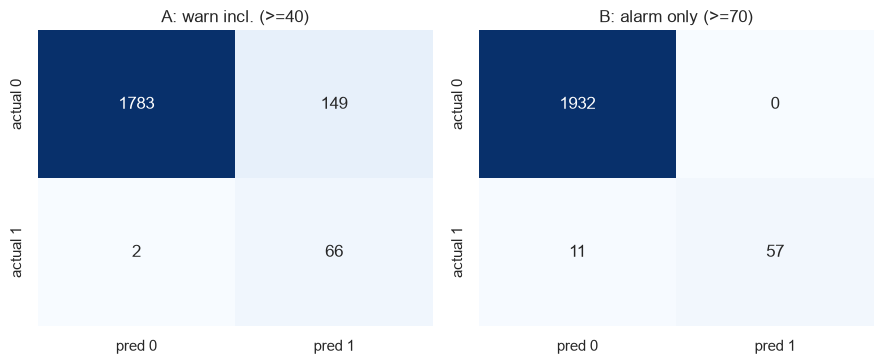

In [10]:
test = df[df["split"] == "test"]
fig, axes = plt.subplots(1, 2, figsize=(9, 3.8))
for ax, name in zip(axes, list(OPERATING_POINTS)[1:]):
    cm = confusion_matrix(test["machineFailure"], OPERATING_POINTS[name](test), labels=[0, 1])
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False, ax=ax,
                xticklabels=["pred 0", "pred 1"], yticklabels=["actual 0", "actual 1"])
    ax.set_title(name.split(" (")[0].replace("A. 경고 포함", "A: warn incl. (>=40)").replace("B. 알람만", "B: alarm only (>=70)"))
plt.tight_layout(); plt.show()

## 7. 정리 — 룰 엔진 1차 성능

**test (2,000행, 고장 68건)**

| 기준 | 정밀도 | 재현율 | F1 | 정확도 |
|---|---|---|---|---|
| 기준선 (모두 정상) | 0.000 | 0.000 | 0.000 | 0.966 |
| A. 경고 포함 (≥40) | 0.307 | 0.971 | 0.466 | 0.924 |
| B. 알람만 (≥70) | 1.000 | 0.838 | 0.912 | 0.994 |

**해석**
- **정확도를 쓰지 않는 이유**: 기준 A는 고장 97%를 잡는데도 정확도(0.924)가 아무것도 안 잡는 기준선(0.966)보다 낮다.
- **기준 B의 정밀도 1.000**은 HDF / PWF / OSF 조건이 데이터 생성 수식과 같기 때문이다. 현실 설비에서는 기대할 수 없는 값이며 README 한계점에 명시한다.
- **기준 A와 B의 차이는 거의 전부 TWF다.** 오탐 678건(전체)은 모두 TWF 경고에서 나왔다.
  toolWear ≥ 200 구간은 train 기준 실제 고장이 15.5%, TWF 라벨은 5.8%뿐이다.
  → 룰로는 "위험 구간"까지만 말할 수 있다. 이 구간 안에서 실제 고장을 가려내는 것이 ML 엔진에 기대하는 역할이다 (면접 질문: *룰이 좋은데 ML은 왜 필요한가?*).
- **기준 A로도 놓친 고장 9건(전체)**: 유형 라벨이 없는 고장 8건 + toolWear 198분에서 난 TWF 1건.
  유형 라벨 없는 고장은 센서값이 정상 범위라 어떤 엔진도 잡기 어려울 것으로 예상된다.
- RNF 19건 중 18건은 `machineFailure = 0`이라 평가에 영향을 주지 않는다.

**Phase 3으로 넘길 것**
- 1절의 경계값 표를 `RuleEngine` 단위 테스트 케이스로 옮긴다.
- `DecisionResult.category`: 한 행에서 여러 조건이 동시에 맞을 수 있음 (단일 값 vs 목록 결정 필요).
- 심각도 값(90 / 40)과 알람 임계값은 Phase 4 `AlertService`에서 확정한다.